In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

from scipy import stats
from scipy.stats.mstats import winsorize

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import PowerTransformer
from sklearn.compose import ColumnTransformer

## Loading Dataset : ( Manufacturing Dataset )

In [2]:
Original_Data = pd.read_csv("smart_manufacturing_dataset.csv")

df = Original_Data.copy()

df.head()

,Machine_ID,Machine_Type,Factory_Location,Operating_Hours_Per_Day,Energy_Consumption_kWh,Production_Output_Units,Defect_Rate_Percent,Maintenance_Level,Temperature_Celsius,Worker_Count,Downtime_Hours_Per_Month,Shift_Type,Last_Service_Date,Supervisor_Name,Efficiency_Score
0,MCH-1000,3D Printer,Rajkot,11,1012.30,1685,9.02,Low,33.3,25,13.3,Evening,2023-12-28,Richard,85.25
1,MCH-1001,NaN,Surat,19,242.66,333,2.03,Medium,23.7,19,1.9,Evening,2023-05-05,Brian,97.04
2,MCH-1002,3D Printer,Vadodara,22,802.90,1349,10.50,High,22.5,26,1.9,Morning,2023-07-03,Krista,87.76
3,MCH-1003,Laser Cutter,Vadodara,20,1614.56,1963,12.06,High,37.0,17,115.8,Morning,2023-03-17,David,78.44
4,MCH-1004,Packaging Unit,Surat,21,694.18,546,11.42,High,29.9,12,1.3,Night,2024-01-15,Sarah,79.81


## Basic Info :

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6620 entries, 0 to 6619
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Machine_ID                6620 non-null   object 
 1   Machine_Type              6222 non-null   object 
 2   Factory_Location          6620 non-null   object 
 3   Operating_Hours_Per_Day   6620 non-null   int64  
 4   Energy_Consumption_kWh    6219 non-null   float64
 5   Production_Output_Units   6620 non-null   int64  
 6   Defect_Rate_Percent       6620 non-null   float64
 7   Maintenance_Level         6238 non-null   object 
 8   Temperature_Celsius       6219 non-null   float64
 9   Worker_Count              6620 non-null   int64  
 10  Downtime_Hours_Per_Month  6620 non-null   float64
 11  Shift_Type                6620 non-null   object 
 12  Last_Service_Date         6620 non-null   object 
 13  Supervisor_Name           6225 non-null   object 
 14  Efficien

,Operating_Hours_Per_Day,Energy_Consumption_kWh,Production_Output_Units,Defect_Rate_Percent,Temperature_Celsius,Worker_Count,Downtime_Hours_Per_Month,Efficiency_Score
count,6620.000000,6219.000000,6620.000000,6620.000000,6219.000000,6620.000000,6620.000000,6620.000000
mean,13.452115,740.555924,1020.795921,7.529435,29.913925,15.645166,8.091994,86.908505
std,5.819460,592.291632,556.633904,4.273597,5.893746,8.172353,8.679691,11.225794
min,4.000000,30.720000,50.000000,0.100000,5.000000,2.000000,0.000000,30.500000
25%,8.000000,445.945000,546.000000,3.950000,25.900000,9.000000,2.300000,79.155000
50%,13.000000,657.120000,1025.000000,7.420000,29.900000,16.000000,5.600000,87.295000
75%,19.000000,910.445000,1492.000000,11.220000,33.900000,23.000000,11.025000,95.100000
max,23.000000,14027.280000,1999.000000,15.000000,53.700000,29.000000,151.200000,114.380000


## EDA : ( Exploratory Data Analysis )

### Univariate Analysis

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2500\3323639917.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Machine_Type', data=df, palette='Set2', ax=axes[2,0])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2500\3323639917.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Maintenance_Level', data=df, palette='coolwarm', ax=axes[2,1])
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2500\3323639917.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Shift_Type', data=df, palette='husl', ax=axes[2,2])


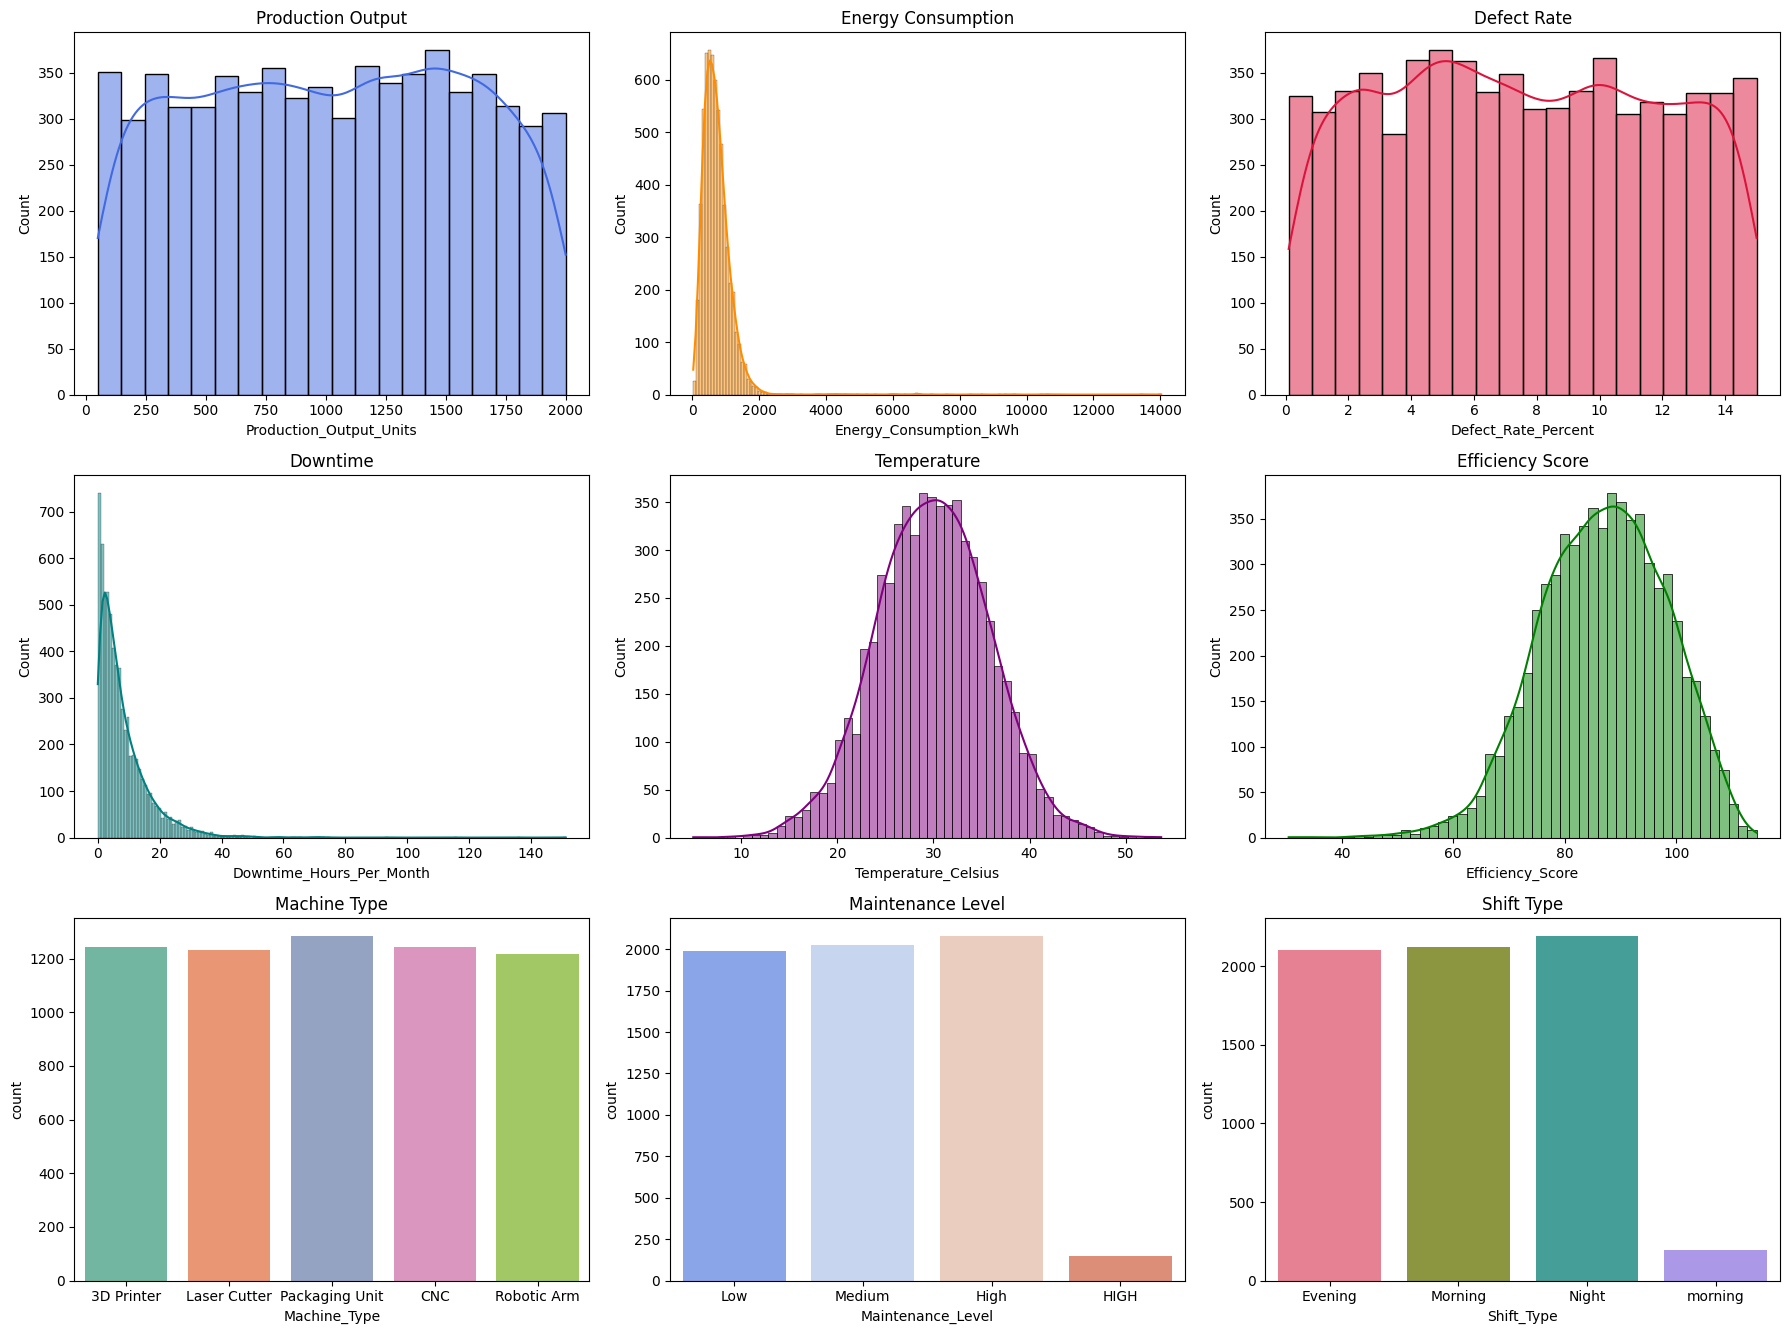

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))

sns.histplot(df['Production_Output_Units'], kde=True, color='royalblue', ax=axes[0,0])
axes[0,0].set_title("Production Output")

sns.histplot(df['Energy_Consumption_kWh'], kde=True, color='darkorange', ax=axes[0,1])
axes[0,1].set_title("Energy Consumption")

sns.histplot(df['Defect_Rate_Percent'], kde=True, color='crimson', ax=axes[0,2])
axes[0,2].set_title("Defect Rate")

sns.histplot(df['Downtime_Hours_Per_Month'], kde=True, color='teal', ax=axes[1,0])
axes[1,0].set_title("Downtime")

sns.histplot(df['Temperature_Celsius'], kde=True, color='purple', ax=axes[1,1])
axes[1,1].set_title("Temperature")

sns.histplot(df['Efficiency_Score'], kde=True, color='green', ax=axes[1,2])
axes[1,2].set_title("Efficiency Score")

sns.countplot(x='Machine_Type', data=df, palette='Set2', ax=axes[2,0])
axes[2,0].set_title("Machine Type")

sns.countplot(x='Maintenance_Level', data=df, palette='coolwarm', ax=axes[2,1])
axes[2,1].set_title("Maintenance Level")

sns.countplot(x='Shift_Type', data=df, palette='husl', ax=axes[2,2])
axes[2,2].set_title("Shift Type")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


### Bivariate Analysis

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2500\2060989510.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Maintenance_Level', y='Efficiency_Score',
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_2500\2060989510.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Shift_Type', y='Downtime_Hours_Per_Month',


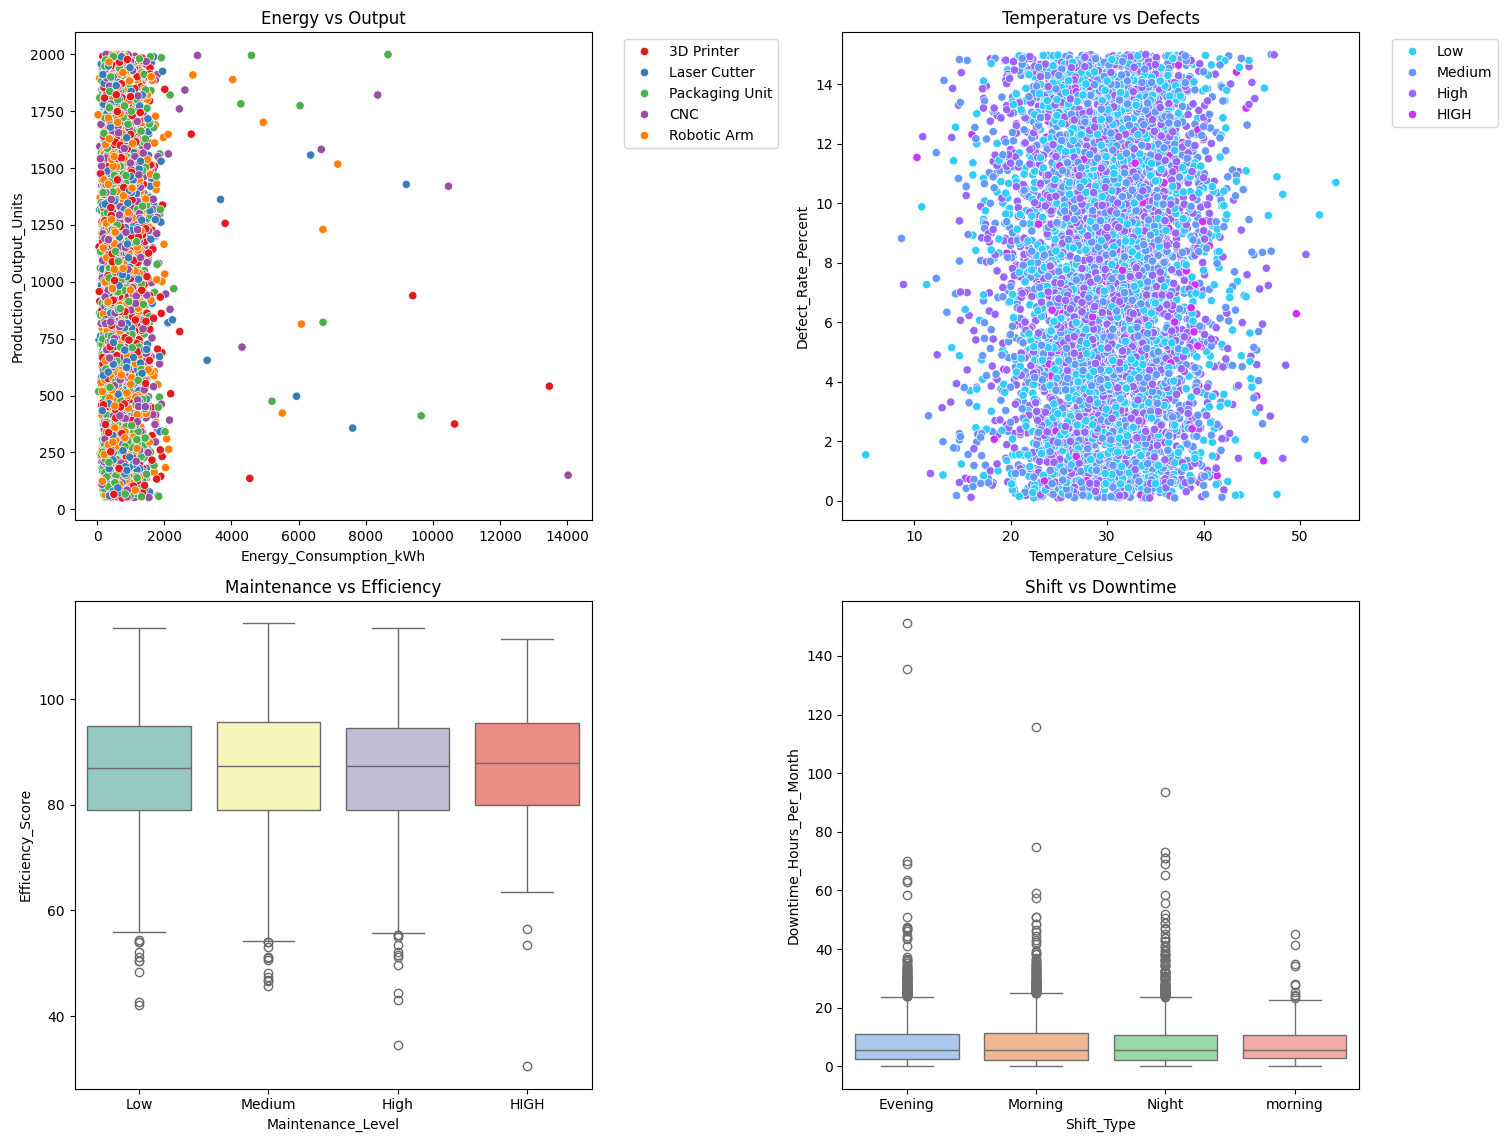

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.scatterplot(x='Energy_Consumption_kWh', y='Production_Output_Units',
                hue='Machine_Type', palette='Set1', data=df, ax=axes[0,0])
axes[0,0].set_title("Energy vs Output")
axes[0,0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

sns.scatterplot(x='Temperature_Celsius', y='Defect_Rate_Percent',
                hue='Maintenance_Level', palette='cool', data=df, ax=axes[0,1])
axes[0,1].set_title("Temperature vs Defects")
axes[0,1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

sns.boxplot(x='Maintenance_Level', y='Efficiency_Score',
            data=df, palette='Set3', ax=axes[1,0])
axes[1,0].set_title("Maintenance vs Efficiency")

sns.boxplot(x='Shift_Type', y='Downtime_Hours_Per_Month',
            data=df, palette='pastel', ax=axes[1,1])
axes[1,1].set_title("Shift vs Downtime")

plt.tight_layout(rect=[0, 0, 0.95, 0.96])
plt.show()

### Multivaraite Analysis

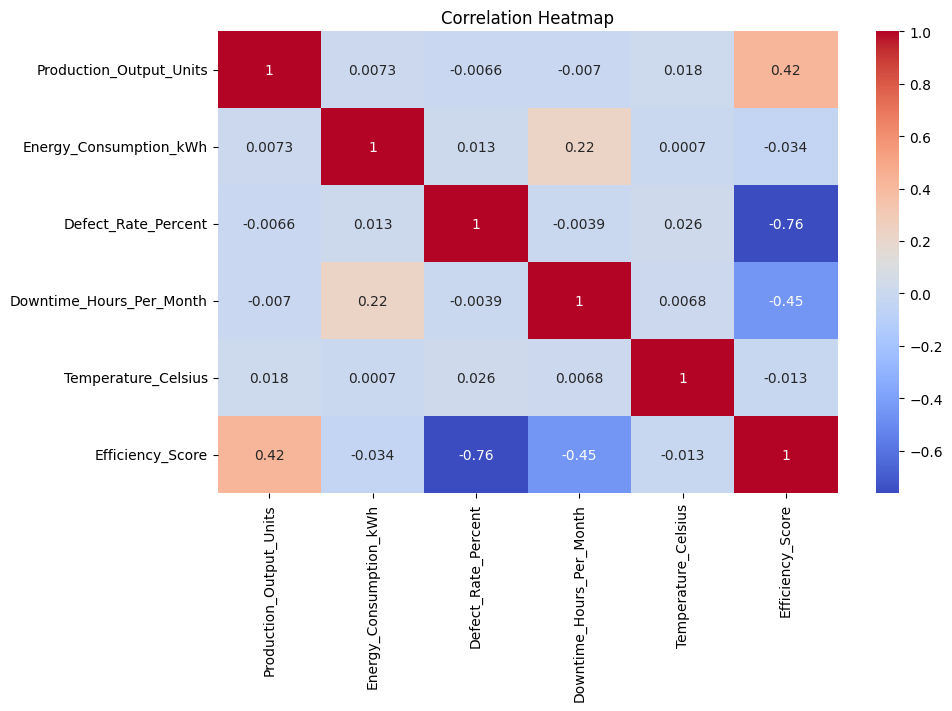

In [8]:
plt.figure(figsize=(10,6))
sns.heatmap(df[['Production_Output_Units','Energy_Consumption_kWh',
                'Defect_Rate_Percent','Downtime_Hours_Per_Month',
                'Temperature_Celsius','Efficiency_Score']].corr(),
            annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

## Missing Value Identification :

In [ ]:
missing_count = df.isnull().sum()
missing_percent = (missing_count/len(df))*100

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Percentage(%)':missing_percent 
})

missing_df

## Dropping Unnecessary Features :

In [ ]:
df = df.drop(columns=['Machine_ID','Supervisor_Name'])


In [ ]:
df.dtypes

## Checking Distribution : (Missing Numerical Feature Only)

In [ ]:
missing_numeric = df[['Energy_Consumption_kWh' , 'Temperature_Celsius']]

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

sns.histplot(df['Energy_Consumption_kWh'], bins=10, kde=True, ax=axes[0], color='forestgreen')
axes[0].set_title('Energy Consumption Distribution')

sns.histplot(df['Temperature_Celsius'], bins=10, kde=True, ax=axes[1], color='sandybrown')
axes[1].set_title('Temperature Distribution')

plt.tight_layout()
plt.show()

## Missing Value Imputation :

In [ ]:
median_imputer = SimpleImputer(strategy="median")

df["Energy_Consumption_kWh"] = median_imputer.fit_transform(df[["Energy_Consumption_kWh"]])

In [ ]:
mean_imputer = SimpleImputer(strategy='mean')

df['Temperature_Celsius'] = mean_imputer.fit_transform(df[['Temperature_Celsius']])

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

sns.histplot(df['Energy_Consumption_kWh'], bins=10, kde=True, ax=axes[0], color='forestgreen')
axes[0].set_title('Energy Consumption Distribution')

sns.histplot(df['Temperature_Celsius'], bins=10, kde=True, ax=axes[1], color='sandybrown')
axes[1].set_title('Temperature Distribution')

plt.tight_layout()
plt.show()

In [ ]:
missing_categorical = df[['Maintenance_Level','Machine_Type']]

def random_impute(col):

    values = col.dropna().values
    
    return col.apply(lambda x: np.random.choice(values) if pd.isna(x) else x)

df['Maintenance_Level'] = random_impute(df['Maintenance_Level'])
df['Machine_Type'] = random_impute(df['Machine_Type'])

In [ ]:
df.isnull().sum()

## Outlier Handling :

In [ ]:
Q1 = df["Energy_Consumption_kWh"].quantile(0.25)
Q3 = df["Energy_Consumption_kWh"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df["Energy_Consumption_kWh"] = np.clip(df["Energy_Consumption_kWh"], lower , upper)

In [ ]:
sns.histplot(df['Energy_Consumption_kWh'], bins=10, kde=True, color='forestgreen')
plt.xlabel('Energy Consumption Distribution')
plt.show()

## Function Transformer :

In [ ]:
df["Energy_Consumption_kWh"] = np.log1p(df["Energy_Consumption_kWh"])

In [ ]:
sns.histplot(df['Energy_Consumption_kWh'], bins=10, kde=True, color='forestgreen')
plt.xlabel('Energy Consumption Distribution')
plt.show()

In [ ]:
df

## Feature Engineering & Encoding :

In [ ]:
df["Last_Service_Date"] = pd.to_datetime(df["Last_Service_Date"])

current_date = pd.Timestamp.today()

df["Days_Since_Service"] = (current_date - df["Last_Service_Date"]).dt.days
df["Service_Year"] = df["Last_Service_Date"].dt.year
df["Service_Month"] = df["Last_Service_Date"].dt.month
df["Service_Day"] = df["Last_Service_Date"].dt.day

In [ ]:
df = df.drop(columns=['Last_Service_Date'])

In [ ]:
df["Output_Per_Worker"] = (
    df["Production_Output_Units"] /
    df["Worker_Count"]
)

In [ ]:
df["Energy_Per_Unit"] = (
    df["Energy_Consumption_kWh"] /
    df["Production_Output_Units"]
)

In [ ]:
df

In [ ]:
df['Output_Per_Worker'] = df['Output_Per_Worker'].round(1)
df['Energy_Per_Unit'] = df['Energy_Per_Unit'].round(3)

In [ ]:
df

In [ ]:
df['Machine_Type'].value_counts()

In [ ]:
df['Maintenance_Level'].value_counts()

In [ ]:
df["Maintenance_Level"] = (
    df["Maintenance_Level"]
    .str.lower()
)

In [ ]:
df['Maintenance_Level'].value_counts()

In [ ]:
Ord_enc = OrdinalEncoder(
    categories=[['low' , 'medium' , 'high']]
)

df['Maintenance_Level'] = Ord_enc.fit_transform(df[['Maintenance_Level']])

In [ ]:
df['Shift_Type'].value_counts()

In [ ]:
df["Shift_Type"] = (
    df["Shift_Type"]
    .str.lower()
)

In [ ]:
df['Shift_Type'].value_counts()

In [ ]:
ohe = OneHotEncoder( drop = 'first', sparse_output = False , handle_unknown = 'ignore')   

cat_cols = ['Machine_Type' , 'Factory_Location' , 'Shift_Type']

encoded_array = ohe.fit_transform(df[cat_cols])

encoded_df = pd.DataFrame(
    encoded_array,
    columns=ohe.get_feature_names_out(cat_cols),
    index=df.index
)

df = df.drop(columns=cat_cols)
df = pd.concat([df, encoded_df], axis=1)

In [ ]:
df

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sns.histplot(df['Operating_Hours_Per_Day'], bins=10, kde=True, ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Operating Hours Distribution')

sns.histplot(df['Energy_Consumption_kWh'], bins=10, kde=True, ax=axes[0,1], color='salmon')
axes[0,1].set_title('Energy Consumption Distribution')

sns.histplot(df['Production_Output_Units'], bins=10, kde=True, ax=axes[1,0], color='forestgreen')
axes[1,0].set_title('Production Output Distribution')

sns.histplot(df['Defect_Rate_Percent'], bins=10, kde=True, ax=axes[1,1], color='sandybrown')
axes[1,1].set_title('Defect Rate Distribution')

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sns.histplot(df['Temperature_Celsius'], bins=10, kde=True, ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Temperature Distribution')

sns.histplot(df['Worker_Count'], bins=10, kde=True, ax=axes[0,1], color='salmon')
axes[0,1].set_title('No. of Worker Distribution')

sns.histplot(df['Downtime_Hours_Per_Month'], bins=10, kde=True, ax=axes[1,0], color='forestgreen')
axes[1,0].set_title('Downtime Hours Distribution')

sns.histplot(df['Efficiency_Score'], bins=10, kde=True, ax=axes[1,1], color='sandybrown')
axes[1,1].set_title('Efficiency Score Distribution')

plt.tight_layout()
plt.show()

## Function Transformer

In [ ]:
df["Downtime_Hours_Per_Month"] = np.log1p(df["Downtime_Hours_Per_Month"])

In [ ]:
sns.histplot(df['Downtime_Hours_Per_Month'], bins=10, kde=True, color='forestgreen')
plt.xlabel('Downtime Hours Distribution')
plt.show()

In [ ]:
df

## Feature Scaling :

In [ ]:
scale_cols = [
    "Operating_Hours_Per_Day","Energy_Consumption_kWh","Production_Output_Units",
    "Defect_Rate_Percent","Temperature_Celsius","Worker_Count",
    "Downtime_Hours_Per_Month","Days_Since_Service","Output_Per_Worker","Energy_Per_Unit"
]

scaler = StandardScaler()

df[scale_cols] = scaler.fit_transform(df[scale_cols])

In [ ]:
Cleaned_Dataset = df.copy()

Cleaned_Dataset.head()